**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 8**
Regresión Lineal

---

*   NOMBRE: Darío Martín Romero Cruz 
*   MATRÍCULA: A01841015

En esta actividad trabajarás con el archivo `diamonds_dataset.csv`, basado en un conjunto de datos sobre características de diamantes, disponible en el paquete ggplot2 de R y en repositorios públicos de análisis de datos.

Los datos fueron recopilados para analizar el precio de los diamantes en función de sus propiedades físicas y cualidades de corte, color y claridad. Los indicadores incluidos son:

* `carat`: Peso del diamante en quilates
* `cut`: Calidad del corte del diamante (Fair, Good, Very Good, Premium, Ideal)
* `color`: Color del diamante, de D (mejor) a J (peor)
* `clarity`: Claridad del diamante (I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF)
* `depth`: Profundidad total del diamante como porcentaje: z / mean(x, y)
* `table`: Ancho de la tabla del diamante como porcentaje de x
* `x`: Longitud en mm
* `y`: Ancho en mm
* `z`: Profundidad en mm
* `price`: Precio del diamante en dólares estadounidenses. Es la variable de salida o *target*

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [20]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error, r2_score

1. Descarga el archivo: `diamonds_dataset.csv` y guarda, en un dataframe (`diamonds_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Verifica si alguna columna contiene valores faltantes.
* Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.

In [21]:
diamonds_df = pd.read_csv('diamonds_dataset.csv', sep = ',') #Leer informacion

#Imprimir resultados
print(f'\nTotal de filas: {diamonds_df.shape[0]:,}')
print(f'Total de columnas: {diamonds_df.shape[1]:,}')
print('\nTipos de datos del archivo:\n')
diamonds_df.info()

#Columnas numericas y categoricas
num_cols = diamonds_df.select_dtypes(include = np.number).columns
cat_cols = diamonds_df.select_dtypes(exclude = np.number).columns
print(f'\nColumnas numéricas: {len(num_cols)}')
print(f'Columnas categóricas: {len(cat_cols)}')

#Revisar valores únicos
print('\nValores únicos por columna:')
print(diamonds_df.nunique(dropna = False).to_string())

#Revisar valores faltantes
print('\nValores faltantes:')
print(diamonds_df.isna().sum().to_string())

#Revisar duplicados
print('\nRegistros duplicados:', diamonds_df.duplicated().sum())
diamonds_df = diamonds_df.drop_duplicates(keep = 'first').reset_index(drop = True)
print(f'\nTotal de filas final: {diamonds_df.shape[0]:,}')



Total de filas: 53,916
Total de columnas: 10

Tipos de datos del archivo:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53916 entries, 0 to 53915
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53916 non-null  float64
 1   cut      53916 non-null  object 
 2   color    53916 non-null  object 
 3   clarity  53916 non-null  object 
 4   depth    53916 non-null  float64
 5   table    53916 non-null  float64
 6   x        53916 non-null  float64
 7   y        53916 non-null  float64
 8   z        53916 non-null  float64
 9   price    53916 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB

Columnas numéricas: 7
Columnas categóricas: 3

Valores únicos por columna:
carat        271
cut            5
color          7
clarity        8
depth        184
table        127
x            550
y            549
z            371
price      11595

Valores faltantes:
carat      0
cut        0
color

**Comentario:**  
* El conjunto tiene **53916 registros y 10 columnas**.
* Con **7 columnas numéricas y 3 de texto (categóricas)**.
* Se eliminaron **145 registros duplicados**.

2. Obtén las estadísticas descriptivas, separando las variables numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Para las variables numéricas genera histogramas y boxplots para explorar la distribución y la dispersión.
* Para las variables categóricas utiliza diagramas de barras para visualizar la frecuencia de cada categoría.


ANALISIS DE LAS VARIABLES NUMERICAS:

Estadistica descriptiva

          carat     depth     table         x         y         z     price
count  53771.00  53771.00  53771.00  53771.00  53771.00  53771.00  53771.00
mean       0.80     61.75     57.46      5.73      5.73      3.54   3930.32
std        0.47      1.43      2.23      1.12      1.14      0.70   3984.69
min        0.20     43.00     43.00      3.73      3.68      1.07    326.00
5%         0.30     59.30     54.00      4.29      4.30      2.65    544.00
50%        0.70     61.80     57.00      5.70      5.71      3.53   2401.00
95%        1.70     63.80     61.00      7.66      7.64      4.73  13086.50
max        4.50     79.00     95.00     10.23     58.90     31.80  18823.00
skew       1.10     -0.11      0.79      0.39      2.47      1.59      1.62
kurt       1.10      5.42      2.78     -0.71     92.45     48.12      2.18

Histogramas y boxplot:


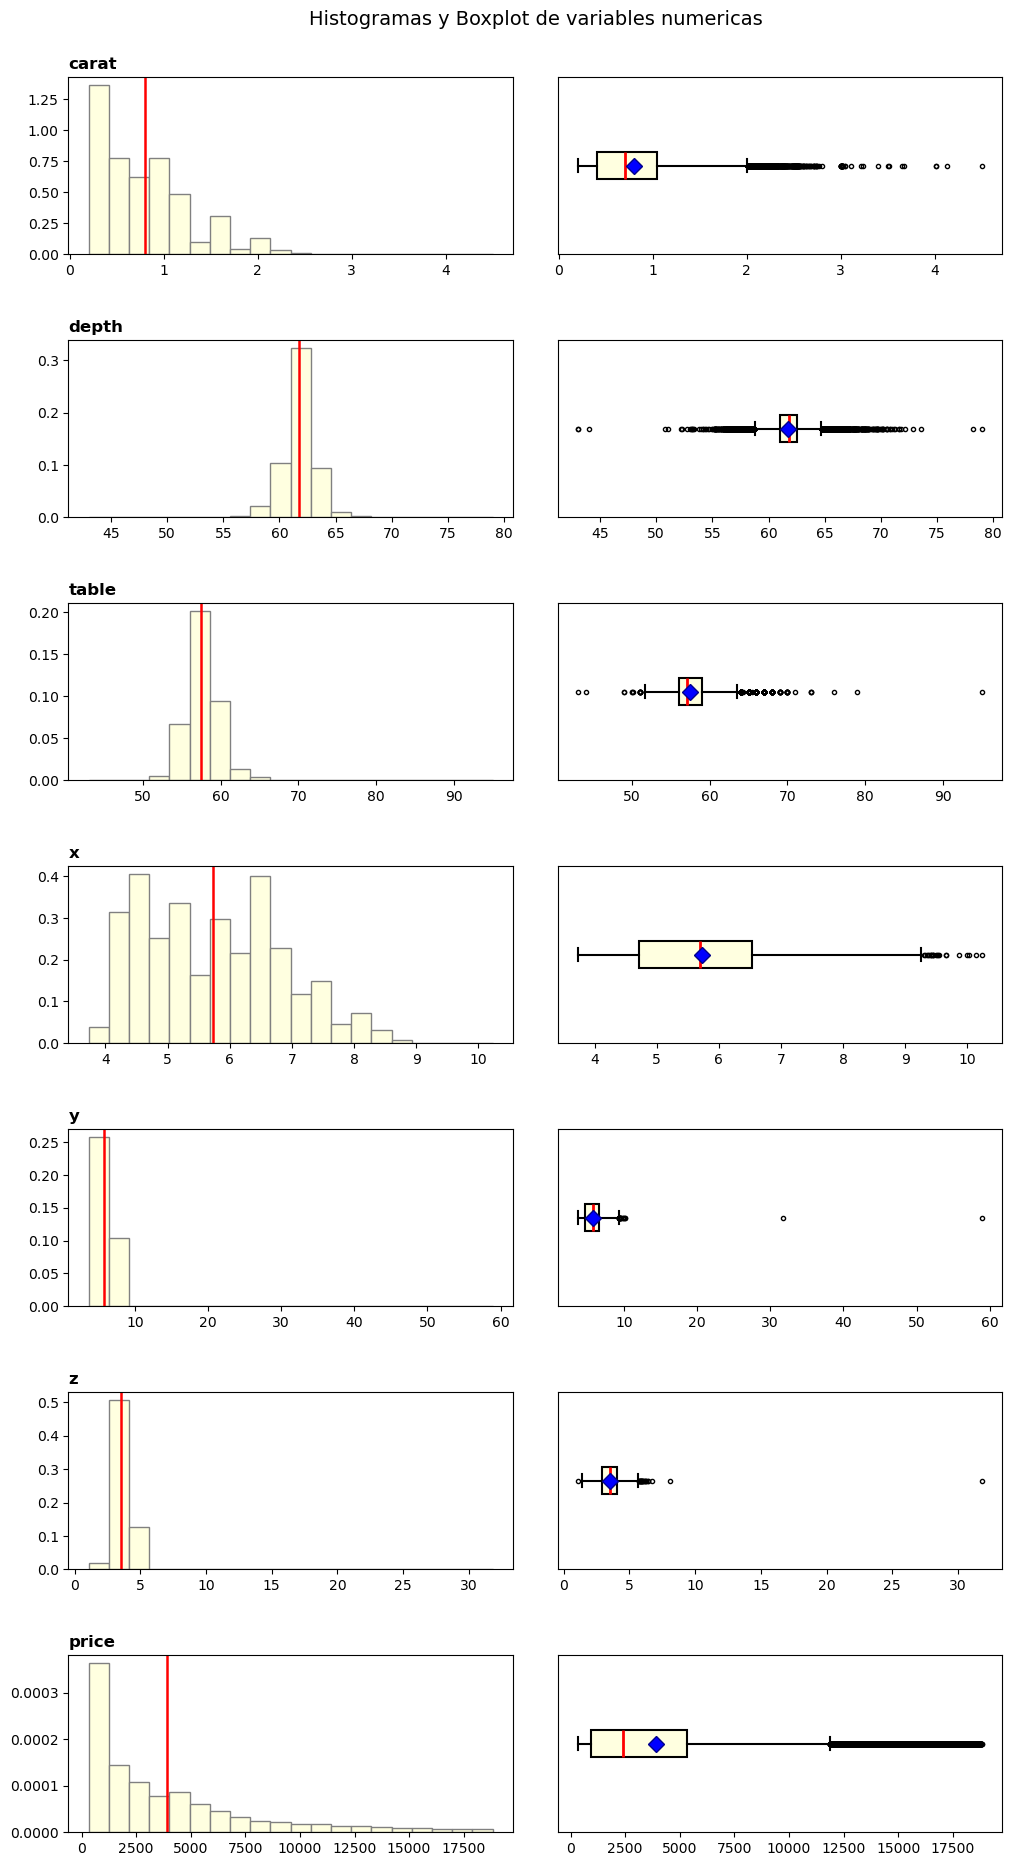


ANALISIS DE LAS VARIABLES CATEGORICAS:

Estadistica descriptiva

          cut  color clarity
count   53771  53771   53771
unique      5      7       8
top     Ideal      G     SI1
freq    21485  11254   13030


Tablas de frecuencia

  > cut
     Ideal: 21485
     Premium: 13737
     Very Good: 12065
     Good: 4888
     Fair: 1596

  > color
     G: 11254
     E: 9776
     F: 9517
     H: 8266
     D: 6753
     I: 5404
     J: 2801

  > clarity
     SI1: 13030
     VS2: 12225
     SI2: 9140
     VS1: 8155
     VVS2: 5056
     VVS1: 3646
     IF: 1784
     I1: 735


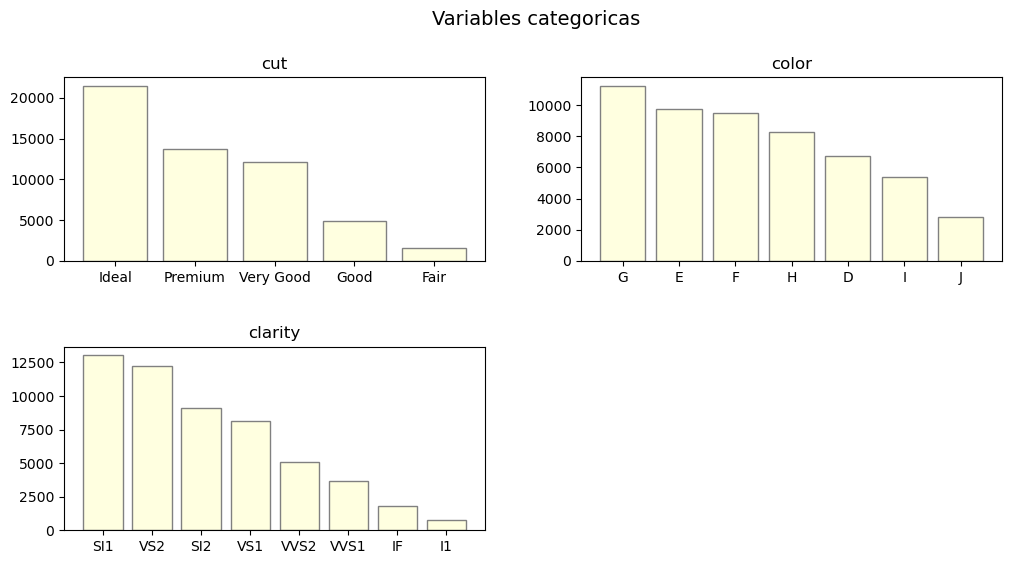

*Variables con mas de 15 categorias: 


In [ ]:
#Obtener estadísticas de las columnas numericas-------------
Stat1 = diamonds_df[num_cols].describe(percentiles = [0.05, 0.95])
Stat1 = pd.concat([Stat1, diamonds_df[num_cols].agg(['skew', 'kurt'])]) #Agregar sesgo y curtosis

#Imprimir resultados
print('\nANALISIS DE LAS VARIABLES NUMERICAS:\n\nEstadistica descriptiva\n')
print(Stat1.round(2))


#Histogramas-------------
print('\nHistogramas y boxplot:')
Fig1 = plt.figure(figsize = (12, 20))
i = 0
for col in num_cols:
    Ax = Fig1.add_subplot(7, 2, 2*i + 1)

    #Histograma
    x = diamonds_df[col]
    Ax.hist(x, bins = 20, density = True, color = 'lightyellow', edgecolor = 'gray') # Histograma normalizado
    Ax.axvline(Stat1.loc['mean', col], color = 'red', ls = '-', lw = 1.8, label = 'Media') #Media
    Ax.set_title(col, fontweight='bold', loc='left')

    #Boxplot
    Ax = Fig1.add_subplot(7, 2, 2*i + 2)
    x = diamonds_df[col]
    Ax.boxplot(x, vert = False, patch_artist = True, boxprops = dict(facecolor = 'lightyellow', lw = 1.5), medianprops = dict(color = 'red', lw = 2), whiskerprops = dict(color = 'black', lw = 1.5), 
               capprops = dict(color = 'black', lw = 1.5), flierprops = dict(marker = 'o', ms = 3),
               showmeans = True, meanprops = dict(marker = 'D', ms = 8, mfc = 'blue', mec = 'darkblue'))

    #Ax.set_title(col)
    Ax.set_yticks([])

    i += 1

Fig1.suptitle('Histogramas y Boxplot de variables numericas', fontsize = 14)    
Fig1.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect = [0.05, 0.05, 0.90, 0.98])
plt.show()




#Obtener estadísticas de las columnas categoricas-------------
Stat2 = diamonds_df[cat_cols].describe()

#Imprimir resultados
print('\nANALISIS DE LAS VARIABLES CATEGORICAS:\n\nEstadistica descriptiva\n')
print(Stat2.round(2))


#Tablas de frecuencia-------------
print('\n\nTablas de frecuencia')
for col in cat_cols:
    print(f'\n  > {col}')
    for val, count in diamonds_df[col].value_counts(dropna = False).items():
        print(f'     {val}: {count}')


#Graficas de barra-------------
Fig2 = plt.figure(figsize = (12, 6))
i = 0

for Col in cat_cols:
    i += 1
    Ax = Fig2.add_subplot(2, 2, i)

    #Grafico de barras
    Counts = diamonds_df[Col].value_counts()

    Ax.bar(Counts.index.astype(str), Counts.values, color = 'lightyellow', edgecolor = 'gray') # Histograma normalizado
    Ax.set_title(Col)

    if len(Counts) > 8:
        Ax.tick_params(axis = 'x', rotation = 20)
        for label in Ax.get_xticklabels():
            label.set_ha('right')

Fig2.suptitle('Variables categoricas', fontsize = 14)
Fig2.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.90, 0.98])
plt.show()

3. Explora relaciones bivariadas en el conjunto de datos mediante gráficos:
* Boxplots que muestren la distribución del precio para cada categoría de color, asegurándose de que las categorías se muestren en el orden de calidad de diamante de mejor a peor: D, E, F, G, H, I, J.
* ¿La tendencia de los precios se comporta como esperabas? Identifica si alguna otra variable podría estar influyendo en la tendencia observada por color y comenta tus observaciones.
* Gráfico de dispersión del precio frente al peso de los diamantes, coloreando los puntos según la categoría de calidad del corte.
* ¿Qué relación se observa entre el peso del diamante y su precio según la calidad del corte?

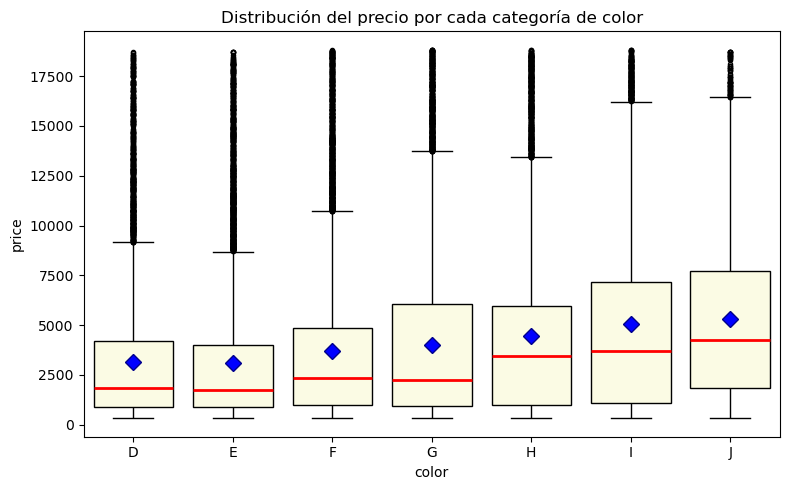

In [ ]:
#Asignar tipo categorico ascendente a color
diamonds_df['color'] = pd.Categorical(diamonds_df['color'], categories=['D', 'E', 'F', 'G', 'H', 'I', 'J'], ordered=True)

#Boxplots para variables numericas---------
fig, ax = plt.subplots(figsize = (8, 5))

sns.boxplot(x = 'color', y = 'price', data = diamonds_df, ax = ax, color = 'lightyellow', fliersize = 3, showmeans = True, linecolor = 'black', 
            medianprops={'color': 'red', 'linewidth': 2, 'linestyle': '-'}, 
            meanprops = {'marker': 'D', 'markerfacecolor': 'blue', 'markeredgecolor': 'darkblue', 'markersize': 8})
            #order=['J', 'I', 'H', 'G', 'F', 'E', 'D'])

ax.set_title('Distribución del precio por cada categoría de color')
plt.tight_layout()
plt.show()

Se observa, contrario a lo esperado, que a mejor color la media y mediana del precio es menor. Probablemente esto quiera decir que hay otros factores en juego. Probablemente el peso.

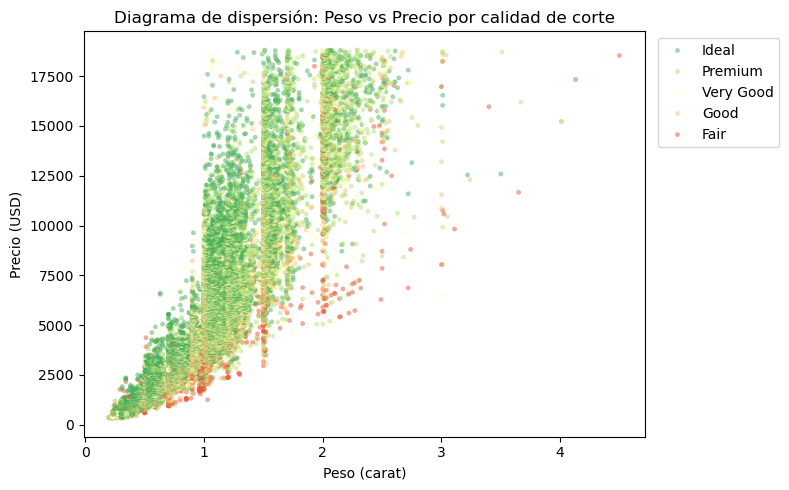

In [ ]:
#Diagrama de dispersion---------
diamonds_df['cut'] = pd.Categorical(diamonds_df['cut'], categories=['Ideal', 'Premium', 'Very Good', 'Good', 'Fair'], ordered=True)

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(data=diamonds_df, x='carat', y='price',
                hue='cut',
                palette='RdYlGn_r',
                s=12,
                alpha = 0.5, edgecolor='none', ax=ax)

ax.set_title('Diagrama de dispersión: Peso vs Precio por calidad de corte')
ax.set_xlabel('Peso (carat)')
ax.set_ylabel('Precio (USD)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

Se observa que el peso si influye fuertemente en el precio. También con el mismo peso, un mejor corte tiende a elevar el precio.

4. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Analiza la correlación entre los predictores (excluyendo `price`), identifica si un único predictor captura información que también está presente en varios otros y elimina los predictores redundantes para simplificar la complejidad de los modelos que construirás más adelante.
* Vuelve a generar el mapa de calor para verificar que ya no queden predictores altamente correlacionados.

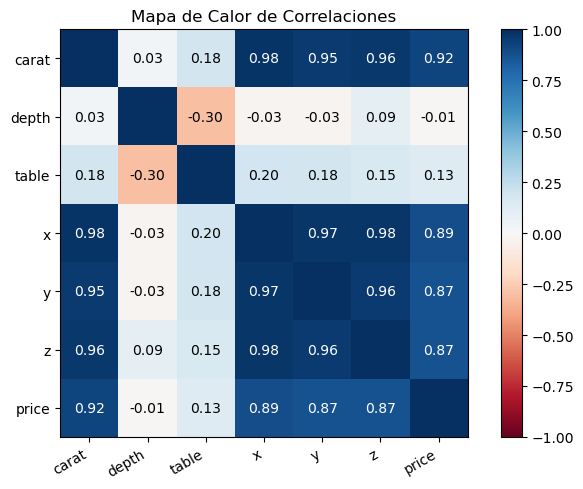

Parejas de variables con alta correlacion:
    Val1   Val2      Corr
0  carat      x  0.978108
1  carat      y  0.954222
2  carat      z  0.961213
3  carat  price  0.921846
4      x      y  0.974799
5      x      z  0.975361
6      y      z  0.956587

Mapa de calor despues de eliminar columnas: x, y, z


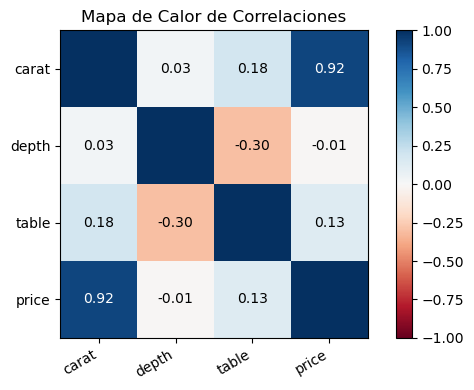

In [25]:
#Tomar solo columnas numericas y aplicar correlación de Pearson
def Mapa_Correlacion(df, cols, size):
    Corr = df[cols].corr(method = 'pearson')
    nCorr = len(Corr.columns)

    #Crear figura
    fig, ax = plt.subplots(figsize = size)

    #Dibujar mapa de calor
    im = ax.imshow(Corr, vmin = -1, vmax = 1, cmap = 'RdBu')

    #Etiquetas
    ax.set_xticks(range(nCorr))
    ax.set_yticks(range(nCorr))

    ax.set_xticklabels(Corr.columns, rotation = 30, ha = 'right')
    ax.set_yticklabels(Corr.columns)

    #Agregar valores
    for i in range(nCorr):
        for j in range(nCorr):
            if i != j:
                TxtColor = 'white' if abs(Corr.iloc[i,j]) > 0.7 else 'black'
                ax.text(j, i, f'{Corr.iloc[i, j]:.2f}', ha = 'center', va = 'center', fontsize = 10, color = TxtColor)

    # Barra de colores
    fig.colorbar(im)
    ax.set_title('Mapa de Calor de Correlaciones')

    fig.tight_layout()
    plt.show()

    return Corr

Corr = Mapa_Correlacion(diamonds_df, num_cols, (7, 5))
high_corr = (Corr.where(np.triu(np.ones(Corr.shape), k=1).astype(bool)).stack()
             .reset_index().rename(columns={'level_0': 'Val1', 'level_1': 'Val2', 0: 'Corr'})
             .query('Corr > 0.9')).reset_index(drop = True)
print('Parejas de variables con alta correlacion:')
print(high_corr)


diamonds_df.drop(columns = ['x', 'y', 'z'], inplace = True)
num_cols = [c for c in num_cols if c not in ['x', 'y', 'z']]

print('\nMapa de calor despues de eliminar columnas: x, y, z')
Corr = Mapa_Correlacion(diamonds_df, num_cols, (6, 4))


**Comentario:**  
Las variables con alta correlación son: `carat`, `x`, `y`, `z` y `price`. Esto tiene sentido considerando que el peso del diamante (`carat`) está directamente correlacionado a sus medidas de longitud, ancho y profundidad. Así podríamos solo quedarnos con este valor para estimar `price`.

5. Construye un modelo de regresión simple utilizando únicamente la variable predictora que tenga la mayor correlación con `price`. Para ello:
* Asigna esta variable a `X` y `price` a `y` y divide el conjunto de datos en entrenamiento y prueba (80:20), usando `random_state=1` para garantizar reproducibilidad.
* Entrena un modelo con `LinearRegression()` de scikit-learn y evalúalo en el conjunto de prueba utilizando las métricas `RMSE` (Root Mean Squared Error) y `R²` (coeficiente de determinación).
* Añade los valores obtenidos a un dataframe de resultados, que incluya el nombre del modelo (*Baseline*) y una columna para cada métrica.
* Muestra la ecuación de la regresión lineal utilizando el intercepto y el coeficiente asociado al predictor. La ecuación debe tener la forma:
> `price = intercepto + coeficiente × predictor`

In [ ]:
X = diamonds_df[['carat']]
y = diamonds_df[['price']]

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size = 0.8, random_state = 1)

model = LinearRegression()
model.fit(Xtrain, ytrain)

predictions_baseline = model.predict(Xtest)
rmse = root_mean_squared_error(ytest, predictions_baseline)
r2   = r2_score(ytest, predictions_baseline)

# Dataframe de resultados
results_df = pd.DataFrame({
    'Model':  ['Baseline'],
    'RMSE':   [round(rmse, 4)],
    'R2':     [round(r2, 4)]
})

print(results_df)

# Ecuación
intercepto  = model.intercept_[0]
coeficiente = model.coef_[0][0]

print(f'\nprice = {intercepto:.4f} + {coeficiente:.4f} × carat')

The Root Mean Square Error (RMSE) is: 1532.438490037521
The R square (R2) is: 0.846180251368926
      Model       RMSE      R2
0  Baseline  1532.4385  0.8462

price = -2276.7895 + 7792.7271 × carat


6. Utiliza todas las variables como predictoras para crear un segundo modelo:
* Haz la asignación correspondiente en `X` y `y` y divide en entrenamiento y prueba usando la misma configuración del ejercicio anterior.
* Prepara un transformador, denominado `preprocessing`, para aplicar escalamiento robusto a los predictores numéricos y codificación ordinal a los categóricos. Asegúrate de respetar el orden correcto de cada categoría, tal como se indica en la descripción de las variables.
* Construye un pipeline que combine el transformador creado con un modelo de regresión lineal.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Ordinal_Robust*.

In [ ]:
num_cols = diamonds_df.select_dtypes(include = np.number).columns
cat_cols = diamonds_df.select_dtypes(exclude = np.number).columns


# Variables
X = diamonds_df.copy()
X[num_cols] = X[num_cols].astype(float)
X[cat_cols] = X[cat_cols].astype(str)
X.drop(columns = 'price', inplace = True)
y = diamonds_df[['price']]

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size=0.8, random_state=1)

# Columnas por tipo
num_cols = ['carat', 'depth', 'table']
cat_cols = ['cut', 'color', 'clarity']

# Orden correcto de cada categoría
cut_order     = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order   = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# Preprocesador
preprocessing = ColumnTransformer(transformers=[
    ('num', RobustScaler(),                               num_cols),
    ('cat', OrdinalEncoder(categories=[cut_order,
                                       color_order,
                                       clarity_order]),  cat_cols)
])

# Pipeline
pipeline = make_pipeline(preprocessing, LinearRegression())

pipeline.fit(Xtrain, ytrain)
predictions_ord = pipeline.predict(Xtest)

rmse = root_mean_squared_error(ytest, predictions_ord)
r2   = r2_score(ytest, predictions_ord)

# Agregar al dataframe de resultados
results_df = pd.concat([
    results_df,
    pd.DataFrame({'Model': ['Ordinal_Robust'], 'RMSE': [round(rmse, 4)], 'R2': [round(r2, 4)]})
], ignore_index=True)

print(results_df)


            Model       RMSE      R2
0        Baseline  1532.4385  0.8462
1  Ordinal_Robust  1216.8222  0.9030


7. Prepara otro transformador, llamado `preprocessing2`, que aplique escalamiento Min-Max a los predictores numéricos y codificación one-hot a los categóricos, asegurando `drop='first'` para prevenir multicolinealidad en las variables dummies generadas.
* Construye otro pipeline utilizando este nuevo transformador y, a continuación, entrena y evalúa el modelo.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *OHE_MinMax*.

In [28]:
#from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Preprocesador 2
preprocessing2 = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(),                     num_cols),
    ('cat', OneHotEncoder(drop='first',
                          sparse_output=False), cat_cols)
])

# Pipeline
pipeline2 = make_pipeline(preprocessing2, LinearRegression())

pipeline2.fit(Xtrain, ytrain)
predictions2 = pipeline2.predict(Xtest)

rmse2 = root_mean_squared_error(ytest, predictions2)
r2_2  = r2_score(ytest, predictions2)

# Agregar al dataframe de resultados
results_df = pd.concat([
    results_df,
    pd.DataFrame({'Model': ['OHE_MinMax'], 'RMSE': [round(rmse2, 4)], 'R2': [round(r2_2, 4)]})
], ignore_index=True)

print(results_df)

            Model       RMSE      R2
0        Baseline  1532.4385  0.8462
1  Ordinal_Robust  1216.8222  0.9030
2      OHE_MinMax  1142.5191  0.9145


8. Modifica el pipeline anterior para emplear regresión polinomial de segundo grado y evalúa si esto mejora el ajuste del modelo.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *PolynomialDegree2*.

In [29]:
# Pipeline con regresión polinomial grado 2
pipeline3 = make_pipeline(
    preprocessing2,
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)

pipeline3.fit(Xtrain, ytrain)
predictions3 = pipeline3.predict(Xtest)

rmse3 = root_mean_squared_error(ytest, predictions3)
r2_3  = r2_score(ytest, predictions3)

# Agregar al dataframe de resultados
results_df = pd.concat([
    results_df,
    pd.DataFrame({'Model': ['PolynomialDegree2'], 'RMSE': [round(rmse3, 4)], 'R2': [round(r2_3, 4)]})
], ignore_index=True)

print(results_df)

               Model       RMSE      R2
0           Baseline  1532.4385  0.8462
1     Ordinal_Robust  1216.8222  0.9030
2         OHE_MinMax  1142.5191  0.9145
3  PolynomialDegree2   748.8384  0.9633


9. Ordena el dataframe de resultados según el `R²`, de manera que el modelo con mejor desempeño aparezca primero.
* Para dicho modelo, crea un gráfico de dispersión de los valores reales frente a los predichos, e incluye una línea diagonal de referencia para indicar una predicción perfecta.

               Model       RMSE      R2
0  PolynomialDegree2   748.8384  0.9633
1         OHE_MinMax  1142.5191  0.9145
2     Ordinal_Robust  1216.8222  0.9030
3           Baseline  1532.4385  0.8462
Mejor modelo: PolynomialDegree2


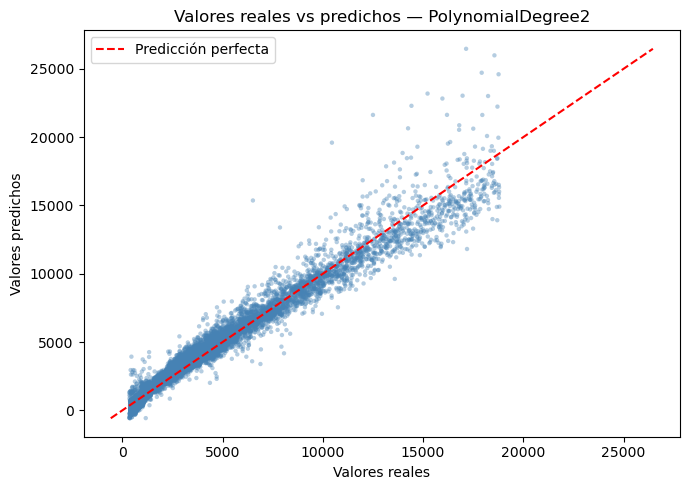

In [ ]:
# Ordenar por R² descendente
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
print(results_df)

best_model = results_df.loc[0, 'Model']
print(f'Mejor modelo: {best_model}')

# Mapear nombre a predicciones
pred_map = {
    'Baseline':          predictions_baseline,
    'Ordinal_Robust':    predictions_ord,
    'OHE_MinMax':        predictions2,
    'PolynomialDegree2': predictions3,
}

best_predictions = pred_map[best_model]

# Gráfico
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(ytest, best_predictions, alpha=0.4, s=10, color='steelblue', edgecolor='none')

# Línea diagonal de referencia (predicción perfecta)
min_val = min(ytest.values.min(), best_predictions.min())
max_val = max(ytest.values.max(), best_predictions.max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=1.5, linestyle='--', label='Predicción perfecta')

ax.set_xlabel('Valores reales')
ax.set_ylabel('Valores predichos')
ax.set_title(f'Valores reales vs predichos — {best_model}')
ax.legend()
plt.tight_layout()
plt.show()


10. Muestra la representación gráfica del pipeline para ubicar la posición de cada elemento dentro del flujo del modelo.
* Obtén los nombres de todas las columnas después del preprocesamiento (numéricas y dummies de categóricas).
* Extrae los nombres de las columnas polinómicas.
* Recupera los coeficientes y el intercepto del modelo de regresión lineal.
* Ordena los coeficientes por su valor absoluto para mostrar los 10 más importantes y da conclusiones sobre cómo los distintos factores influyen en el precio.

In [31]:
from sklearn import set_config

# Representación gráfica del pipeline
set_config(display='diagram')
display(pipeline3)

# Nombres de columnas tras preprocesamiento
ohe_features = (pipeline3
                .named_steps['columntransformer']
                .named_transformers_['cat']
                .get_feature_names_out(cat_cols)
                .tolist())

all_features = num_cols + ohe_features

# Nombres de columnas polinómicas
poly_features = (pipeline3
                 .named_steps['polynomialfeatures']
                 .get_feature_names_out(all_features)
                 .tolist())

# Coeficientes e intercepto
coef       = pipeline3.named_steps['linearregression'].coef_[0]
intercepto = pipeline3.named_steps['linearregression'].intercept_[0]

print(f'Intercepto: {intercepto:.4f}')
print(f'Total features polinómicas: {len(poly_features)}\n')

# Top 10 coeficientes por valor absoluto
coef_df = (pd.DataFrame({'Feature': poly_features, 'Coeficiente': coef})
           .assign(Abs=lambda df: df['Coeficiente'].abs())
           .sort_values('Abs', ascending=False)
           .drop(columns='Abs')
           .head(10)
           .reset_index(drop=True))

print(coef_df)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('polynomialfeatures', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

Intercepto: -1619.5628
Total features polinómicas: 230

              Feature   Coeficiente
0             carat^2  55138.497649
1    carat clarity_IF  49898.316662
2  carat clarity_VVS1  46662.337832
3  carat clarity_VVS2  44769.175537
4   carat clarity_VS1  40020.571581
5   carat clarity_VS2  37083.049534
6   carat clarity_SI1  31988.729725
7   carat clarity_SI2  24361.063098
8       carat color_J -20652.315075
9       carat color_I -14269.632273


**Comentario**  
* Los 10 coeficientes más grandes son todos términos con `carat` (ya sea carat² o sus interacciones), así que queda claro que el tamaño es lo que más pesa en el precio. El carat² sale positivo, o sea que la relación es convexa: el precio sube más rápido conforme crece el peso. Eso explica por qué el modelo polinomial le gana a los lineales.
* La claridad y el color no suman un monto fijo, más bien ajustan cuánto vale cada quilate. Las interacciones `carat × clarity` son positivas y van en el orden esperado (IF > VVS1 > VVS2 > VS1 > VS2 > SI1 > SI2, todas comparadas contra I1, que es la *baseline*): a mejor claridad, más vale el quilate. Las de `carat × color` salen negativas para los peores colores (J e I, contra la *baseline D*), así que un color más bajo le resta valor.
* Hay que tener cuidado al leer las magnitudes: como escalé los numéricos con Min-Max, esos ~50,000 son el efecto sobre todo el rango de tamaños, no dólares por quilate físico. El intercepto negativo tampoco se interpreta solo, es nada más el punto donde el modelo arranca cuando todo vale cero escalado.

---

**Declaración de uso de IA**

*Anthropic. (2026). Claude Sonnet 4.6 [Modelo de lenguaje grande], utilizado para generación de código y depuración. https://claude.ai/

---